In [ ]:
import pandas as pd
df = pd.read_parquet(r"C:\hackathon\PS-03\model\finaldataset.parquet")
df

,Date,latitude,longitude,pm25,pm10,img_mir_radiance,img_mir_temp,img_swir_radiance,img_tir1_radiance,img_tir1_temp,...,img_vis_albedo,img_wv_radiance,img_wv_temp,PBLH,avg_population,sat_azimuth,sat_elevation,sun_azimuth,sun_elevation,lulc
0,2021-01-15,8.514909,76.943588,16.520000,37.840000,0.043679,290.781586,1.312773,0.520951,263.632935,...,13.258400,0.092012,231.339325,667.463562,176540.915286,14840.473684,7822.263158,20924.368421,5600.421053,16.0
1,2021-01-15,8.524112,76.936057,33.000000,51.750000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
2,2021-01-15,8.524112,76.936057,33.000000,38.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
3,2021-01-15,8.524112,76.936057,33.000000,33.500000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
4,2021-01-15,8.524112,76.936057,33.000000,39.000000,0.043498,290.683807,1.350298,0.521067,263.644684,...,13.710799,0.091692,231.251984,667.463562,176540.915286,14838.789474,7821.000000,20922.631579,5600.157895,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395094,2023-11-15,34.065992,74.827902,61.900000,69.700000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395095,2023-11-15,34.065992,74.827902,61.900000,70.000000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395096,2023-11-15,34.065992,74.827902,61.900000,188.100000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0
395097,2023-11-15,34.065992,74.827902,61.900000,187.500000,0.052602,295.190308,0.997179,0.814765,289.112488,...,12.606668,0.168452,247.971497,2206.166504,152346.441429,16816.000000,5065.187500,20389.187500,3518.312500,16.0


In [ ]:
import pandas as pd
import numpy as np
import warnings
import optuna
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import shap
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === Load dataset ===
tqdm.write("📥 Loading dataset...")
df = df
df= df.sample(n=100000,replace=True,random_state =42)
# === Feature Engineering ===
tqdm.write("⚒ Performing feature engineering...")

df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['pm10'] = df['pm10']
df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
# df['inversion_flag'] = (df['temp_diff_tir'] > 0).astype(int)
df['sat_view_obliquity'] = 90 - df['sat_elevation']   # how slanted the satellite view is
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])  # illumination-view difference
df['sun_obliquity'] = 90 - df['sun_elevation']  # how low the sun is

features = [
    'latitude', 'longitude', 'img_mir_radiance', #'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance'',,'sun_elevation' ,'sun_view_angle_diff','sat_view_obliquity',, 'tir_radiance_diff',  'img_vis_radiance''inversion_flag','cloud_flag','cloud_score'
    'img_swir_radiance','smoke_index_temp','sun_azimuth', 
    'img_vis_albedo','avg_population','PBLH', 'lulc','sun_obliquity','sat_elevation', 'img_wv_radiance','img_wv_temp',
    'temp_diff_tir','img_mir_temp','sat_azimuth',
]
target = 'pm10'

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Scaling ===
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # === RFECV ===
# tqdm.write("🧪 Step 1: RFECV for initial feature pruning...")
# cv = KFold(n_splits=10, shuffle=True, random_state=42)
# rfecv = RFECV(estimator=Ridge(), step=1, cv=cv, scoring='r2', min_features_to_select=20)
# rfecv.fit(X_train_scaled, y_train)

# X_train_selected = rfecv.transform(X_train_scaled)
# X_test_selected = rfecv.transform(X_test_scaled)
# selected_features = X.columns[rfecv.support_]
# removed_features_rfecv = list(X.columns[~rfecv.support_])
# tqdm.write(f"❌ RFECV removed features: {removed_features_rfecv}")
# tqdm.write(f"✅ Features after RFECV: {list(selected_features)}")

# X_all_scaled = scaler.transform(X)
# X_reduced = rfecv.transform(X_all_scaled)
# y_reduced = y.reset_index(drop=True)

# === Optuna Tuning ===

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 600),
        'max_depth': trial.suggest_int('max_depth', 6, 30),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42
        # 🔥 Remove 'device': 'gpu' here
    }
    model = LGBMRegressor(**params)
    return cross_val_score(model, X, y, cv=5, scoring='r2').mean()


tqdm.write("🔍 Step 2: Tuning LightGBM with Optuna...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
best_lgb_params = study_lgb.best_params

# === Train Final Model ===
lgb_best = LGBMRegressor(**best_lgb_params)
lgb_best.fit(X_train, y_train)

# === Evaluation ===
y_pred = lgb_best.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 Model Evaluation:")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")









📥 Loading dataset...
⚒ Performing feature engineering...


[I 2025-08-08 02:50:32,438] A new study created in memory with name: no-name-687b6a8a-c443-4921-8e34-a82cdb9c0c85


🔍 Step 2: Tuning LightGBM with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4186
[LightGBM] [Info] Number of data points in the train set: 77553, number of used features: 17
[LightGBM] [Info] Start training from score 109.076481
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4182
[LightGBM] [Info] Number of data points in the train set: 77553, number of used features: 17
[LightGBM] [Info] Start training from score 109.335567
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4185
[LightGBM] [Info] Number of data points in the train set: 77554, number of used features: 17
[LightGBM] [Info] Start

In [16]:
tqdm.write("🧮 Permutation Importance...")
perm = permutation_importance(lgb_best, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\n📌 Permutation Importance:")
print(perm_importances)

🧮 Permutation Importance...

📌 Permutation Importance:
              Feature  Importance
5         sun_azimuth    0.160801
7      avg_population    0.148219
8                PBLH    0.121230
14      temp_diff_tir    0.083062
4    smoke_index_temp    0.059881
0            latitude    0.059003
16        sat_azimuth    0.033197
11      sat_elevation    0.029687
6      img_vis_albedo    0.027012
9                lulc    0.026486
3   img_swir_radiance    0.026412
10      sun_obliquity    0.025688
2    img_mir_radiance    0.025669
1           longitude    0.024827
12    img_wv_radiance    0.018035
15       img_mir_temp    0.007792
13        img_wv_temp    0.003653


📈 SHAP Analysis (No RFECV)...


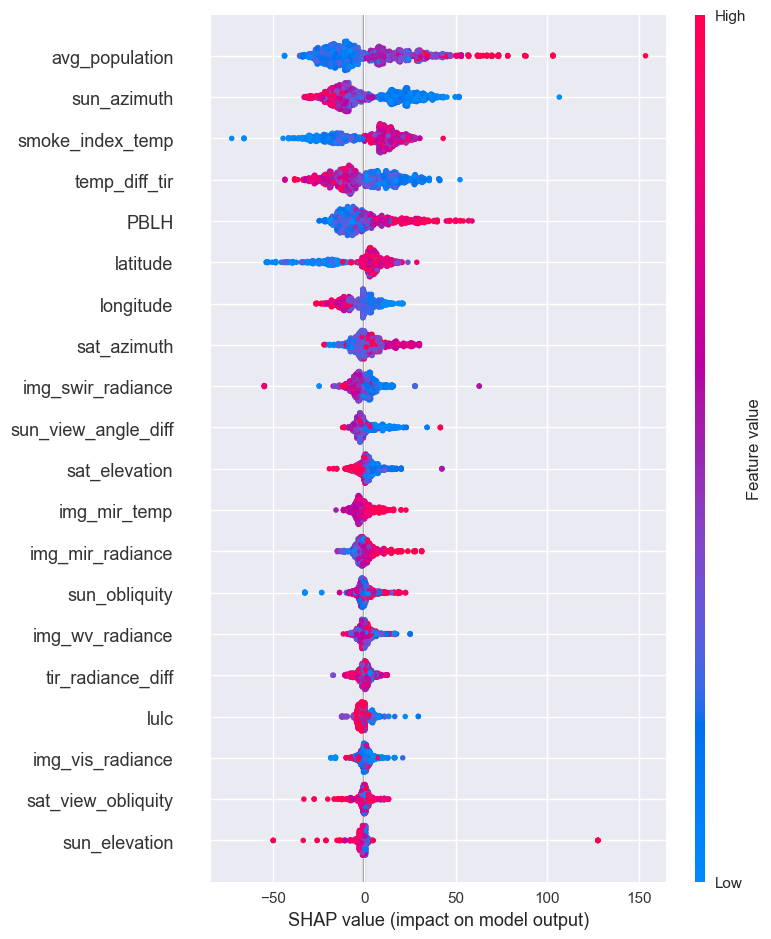

In [11]:
tqdm.write("📈 SHAP Analysis (No RFECV)...")

# Sample from X_test
X_shap_sample_df = X_test.sample(n=1500, random_state=42)

# SHAP Explainer
explainer = shap.TreeExplainer(lgb_best)
shap_values = explainer.shap_values(X_shap_sample_df)

# Summary Plot
shap.summary_plot(shap_values, features=X_shap_sample_df, feature_names=X_shap_sample_df.columns)

In [12]:
tqdm.write("📉 Error Clustering...")

# Calculate errors
errors = y_test - y_pred

# Use full feature set
error_df = pd.DataFrame(X_test.copy())
error_df['Error'] = errors.values

# Select top 10% largest absolute errors
error_cluster = error_df[error_df['Error'].abs() > np.percentile(abs(errors), 90)]

# Print descriptive stats
print("\n🔥 Top 10% Error Cluster:")
print(error_cluster.describe())

📉 Error Clustering...

🔥 Top 10% Error Cluster:
          latitude    longitude  img_mir_radiance  img_swir_radiance  \
count  1998.000000  1998.000000       1998.000000        1998.000000   
mean     25.162920    79.909207          0.081021           1.316677   
std       5.369445     5.483317          0.028154           0.427217   
min       8.524112    72.587270          0.008900           0.507176   
25%      20.945818    76.791360          0.064804           1.052142   
50%      25.609324    77.064466          0.079114           1.241922   
75%      28.608282    85.123525          0.098008           1.568529   
max      34.065992    93.927888          0.157366           3.251712   

       img_vis_radiance  smoke_index_temp   sun_azimuth  img_vis_albedo  \
count       1998.000000       1998.000000   1998.000000     1998.000000   
mean           6.819437         63.672635  22222.790637       18.077830   
std            5.994033         29.297753   2050.696017       10.843516   
min